# Full EEG pipeline + FBCCA

Steps:
1. Load BCI2000 recording
2. Bandpass filter [1–55 Hz]
3. Re-reference to average
4. ICA (extended Infomax)
5. ICLabel — classify components
6. Inspect ICA components
7. Remove artifact ICs
8. Before / after comparison
9. Create epochs [0–3 s from stim onset]
10. FBCCA — compute score per epoch
11. Plot FBCCA stream

In [1]:
print("y si prendes un muneco")

y si prendes un muneco


In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path("../..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from eeg.io import load_bci2k
from eeg.inspect import print_summary
from eeg.preprocessing import (
    bandpass_filter,
    rereference_average,
    run_ica,
    label_components,
    remove_artifacts,
    make_epochs,
)
from eeg.fbcca import run_fbcca
from eeg.viz import (
    plot_stim_channel,
    plot_channels,
    plot_channels_psd,
    plot_ica_components,
    plot_before_after,
    plot_fbcca_stream,
)

DATA_FILE = PROJECT_ROOT / "data/eeg/raw/MET000bGridFixedS001R02.dat"

## 1. Load

In [3]:
raw = load_bci2k(DATA_FILE)
print_summary(raw)

Creating RawArray with float64 data, n_channels=1, n_times=209984
    Range : 0 ... 209983 =      0.000 ...   410.123 secs
Ready.
EEG channels (32): ['PO7', 'O1', 'Oz', 'O2', 'PO8', 'PO4', 'POz', 'PO3', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'CP6', 'CP2', 'CPz', 'CP1', 'CP5', 'C5', 'FC5', 'FC1', 'Cz', 'FC2', 'F4', 'FC6', 'C6', 'Fz', 'F3', 'AF3', 'AF4']
All channels (33): ['PO7', 'O1', 'Oz', 'O2', 'PO8', 'PO4', 'POz', 'PO3', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'CP6', 'CP2', 'CPz', 'CP1', 'CP5', 'C5', 'FC5', 'FC1', 'Cz', 'FC2', 'F4', 'FC6', 'C6', 'Fz', 'F3', 'AF3', 'AF4', 'STI 014']
Sampling rate: 512.0 Hz
Duration: 410.12 s
Montage: <DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 32 channels>
Stimulus channel: STI 014 (from DigitalInput1)
Finding events on: STI 014
104 events found on stim channel STI 014
Event IDs: [1]
DigitalInput1 rising edges: 104
Events (find_events): 104
Event counts: {1: 104}


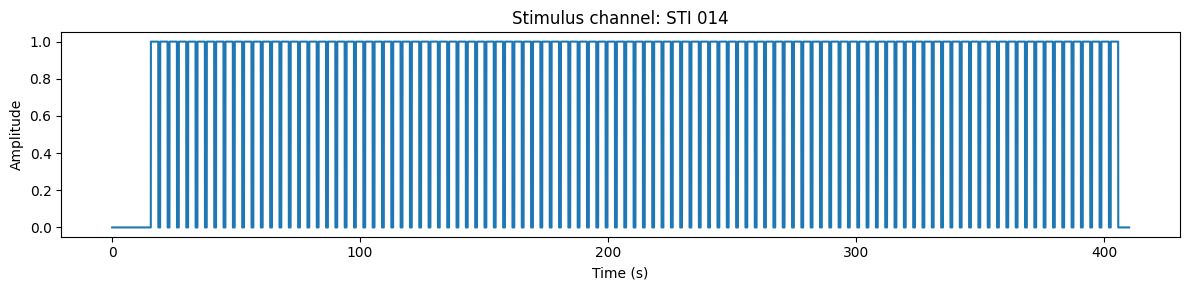

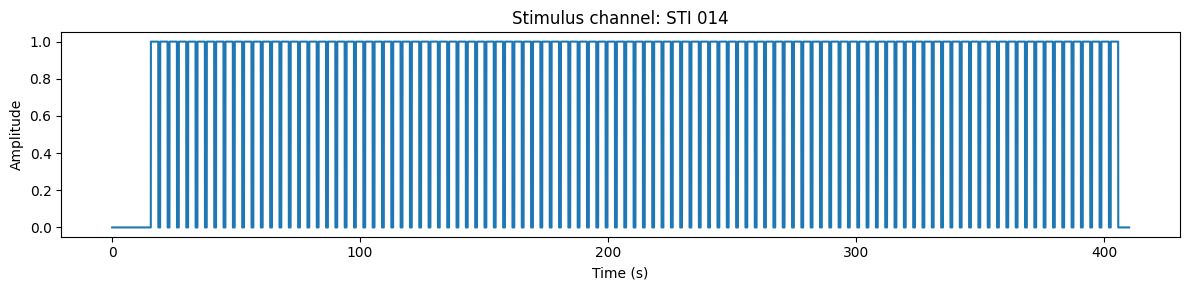

In [4]:
plot_stim_channel(raw, duration=600)

## 2. Bandpass filter

In [6]:
L_FREQ = 1.0
H_FREQ = 55.0
FILTER_ORDER = 4

bandpass_filter(raw, l_freq=L_FREQ, h_freq=H_FREQ, order=FILTER_ORDER)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 55 Hz



IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 55.00 Hz: -6.02, -6.02 dB



<RawBCI2k | MET000bGridFixedS001R02.dat, 33 x 209984 (410.1 s), ~52.9 MiB, data loaded>

## 3. Re-reference to average

In [7]:
rereference_average(raw)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawBCI2k | MET000bGridFixedS001R02.dat, 33 x 209984 (410.1 s), ~52.9 MiB, data loaded>

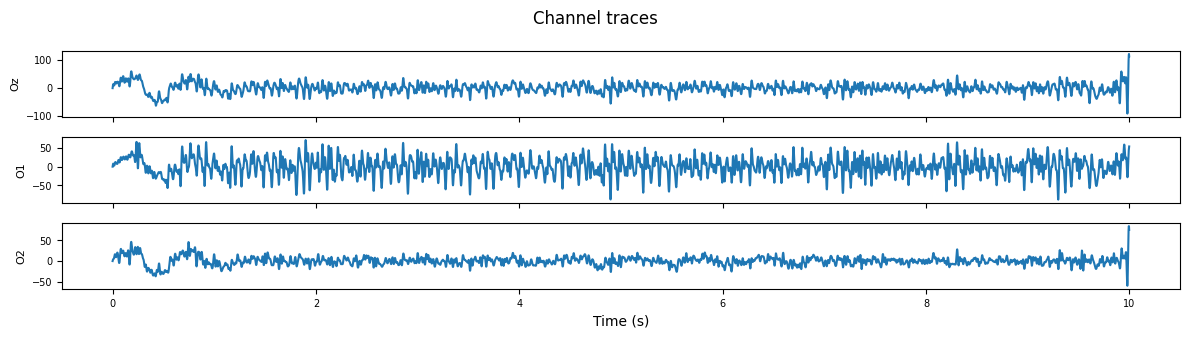

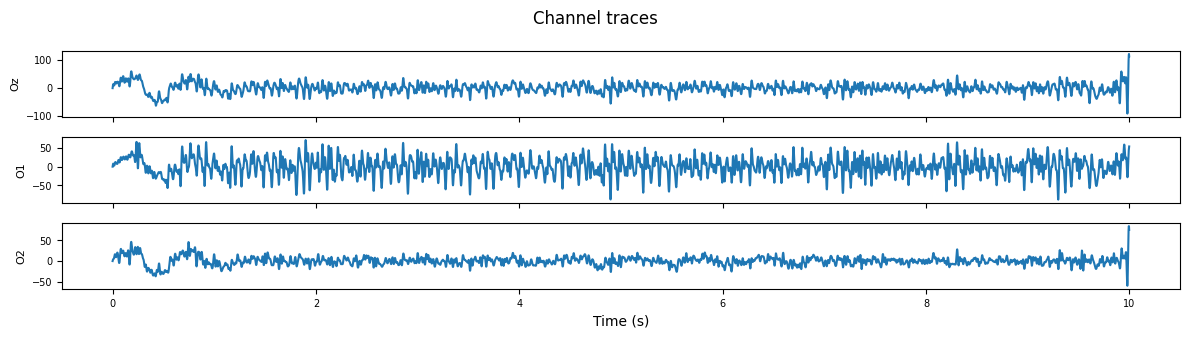

In [8]:
# Spot-check: occipital channels after filtering + reref
CHANNELS = ["Oz", "O1", "O2"]

plot_channels(raw, CHANNELS, duration=10.0)

Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


/home/zevaz/projects/dataAnalysisCursor/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


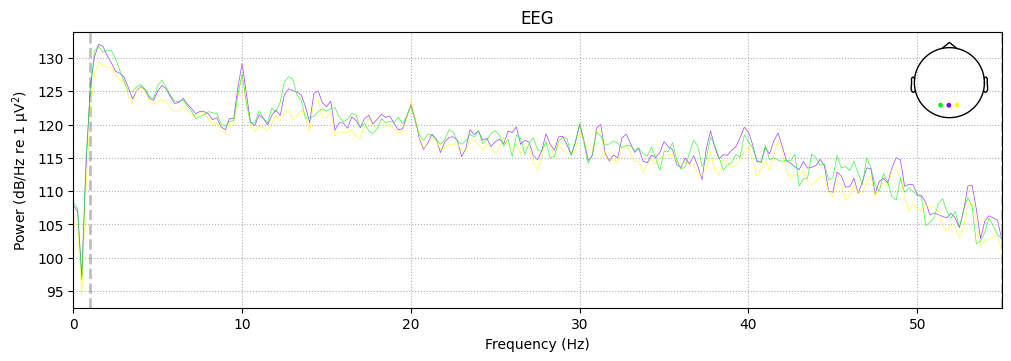

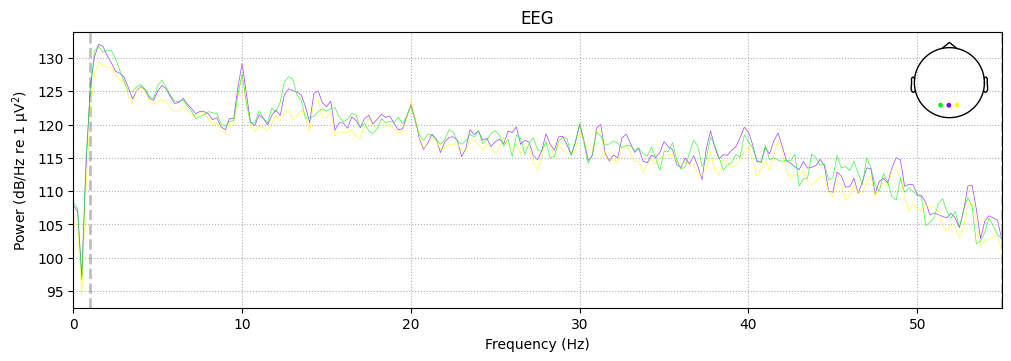

In [9]:
plot_channels_psd(raw, CHANNELS, fmax=55.0)

## 4. ICA

Takes ~60–90 seconds.

In [10]:
N_COMPONENTS = 24

ica = run_ica(raw, n_components=N_COMPONENTS)
print(ica)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 24 components
Computing Extended Infomax ICA
Fitting ICA took 35.8s.
<ICA | raw data decomposition, method: infomax (fit in 156 iterations on 209984 samples), 24 ICA components (32 PCA components available), channel types: eeg, no sources marked for exclusion>


## 5. ICLabel — classify components

In [11]:
labels = label_components(raw, ica)

for i, (label, proba) in enumerate(zip(labels["labels"], labels["y_pred_proba"])):
    print(f"IC {i:02d}: {label} ({proba.max():.0%})")

/home/zevaz/projects/dataAnalysisCursor/src/eeg/preprocessing.py:54: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  return mne_icalabel.label_components(raw, ica, method="iclabel")


IC 00: other (86%)
IC 01: eye blink (95%)
IC 02: brain (100%)
IC 03: brain (96%)
IC 04: brain (99%)
IC 05: brain (100%)
IC 06: brain (98%)
IC 07: muscle artifact (42%)
IC 08: brain (92%)
IC 09: brain (98%)
IC 10: eye blink (84%)
IC 11: brain (94%)
IC 12: brain (56%)
IC 13: brain (45%)
IC 14: brain (99%)
IC 15: other (34%)
IC 16: other (63%)
IC 17: brain (100%)
IC 18: other (48%)
IC 19: other (53%)
IC 20: brain (81%)
IC 21: brain (64%)
IC 22: brain (97%)
IC 23: other (49%)


## 6. Inspect ICA components

Edit `COMPONENT_INDICES` to examine any subset. Look for eye blinks (large frontal topography + slow time course) and muscle artifacts (high-frequency spectrum + peripheral topography).

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated


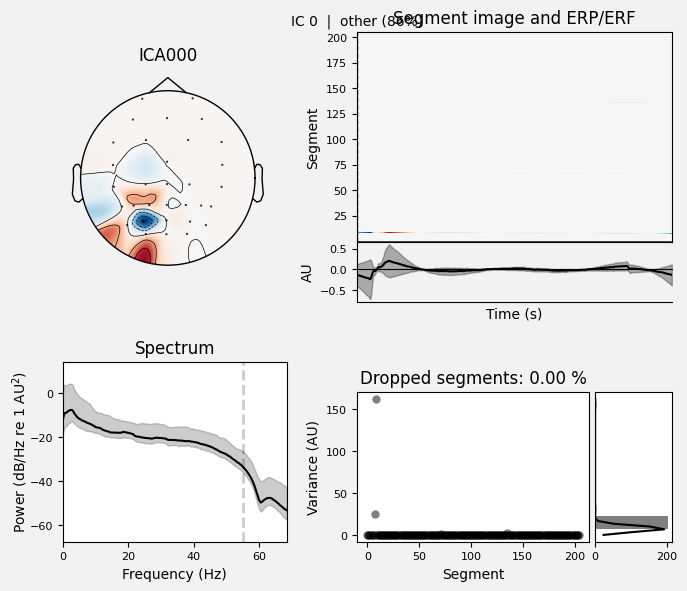

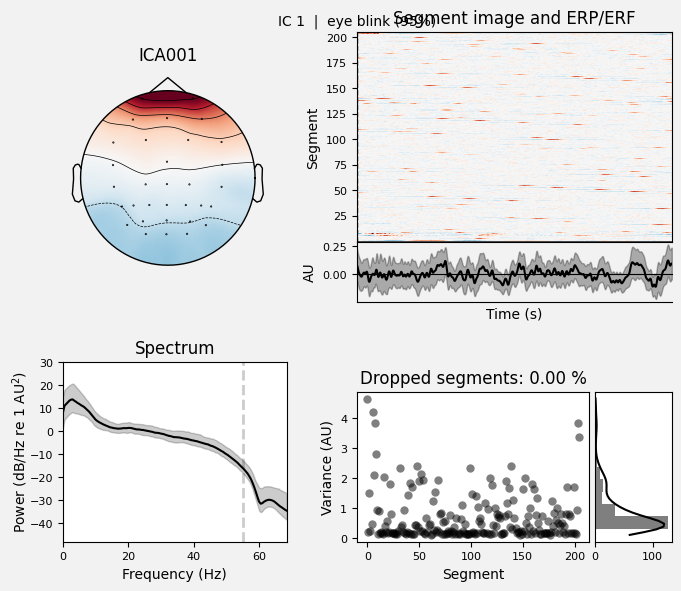

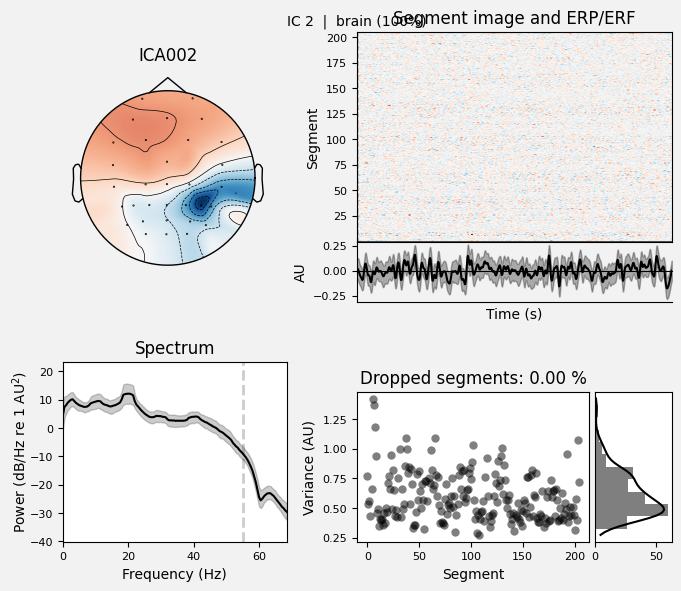

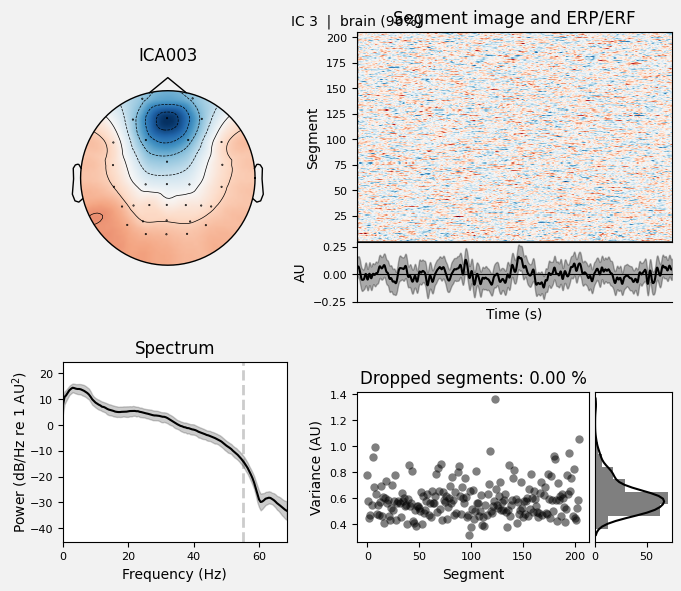

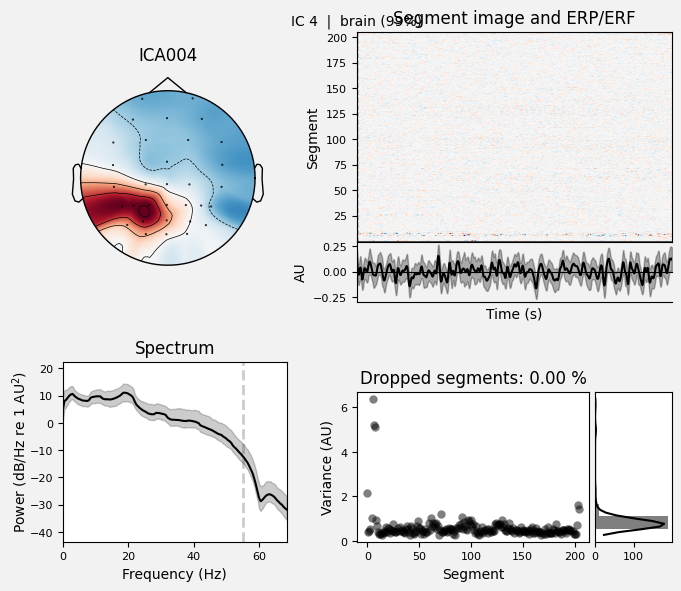

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [12]:
COMPONENT_INDICES = [0, 1, 2, 3, 4]

plot_ica_components(raw, ica, COMPONENT_INDICES, labels=labels)

## 7. Remove artifact ICs

Components are excluded automatically when ICLabel probability exceeds the thresholds below. Adjust thresholds if you want to be more or less conservative.

In [13]:
EYE_THRESHOLD    = 0.7   # exclude eye blink ICs above this probability
MUSCLE_THRESHOLD = 0.5   # exclude muscle artifact ICs above this probability

raw_clean, excluded = remove_artifacts(
    raw, ica, labels,
    eye_threshold=EYE_THRESHOLD,
    muscle_threshold=MUSCLE_THRESHOLD,
)

print(f"Excluded ICs: {excluded}")
print(f"Labels of excluded ICs: {[labels['labels'][i] for i in excluded]}")

Applying ICA to Raw instance
    Transforming to ICA space (24 components)
    Zeroing out 2 ICA components
    Projecting back using 32 PCA components
Excluded ICs: [1, 10]
Labels of excluded ICs: ['eye blink', 'eye blink']


## 8. Before / after comparison

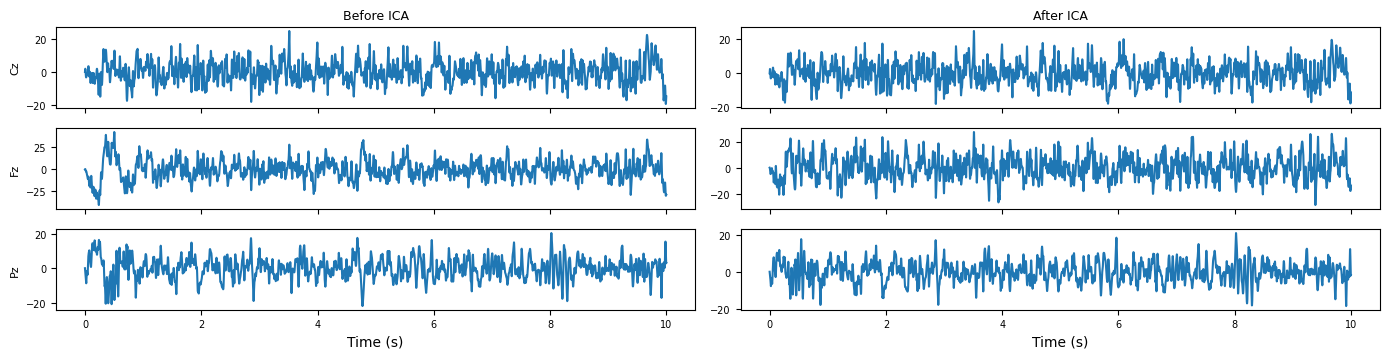

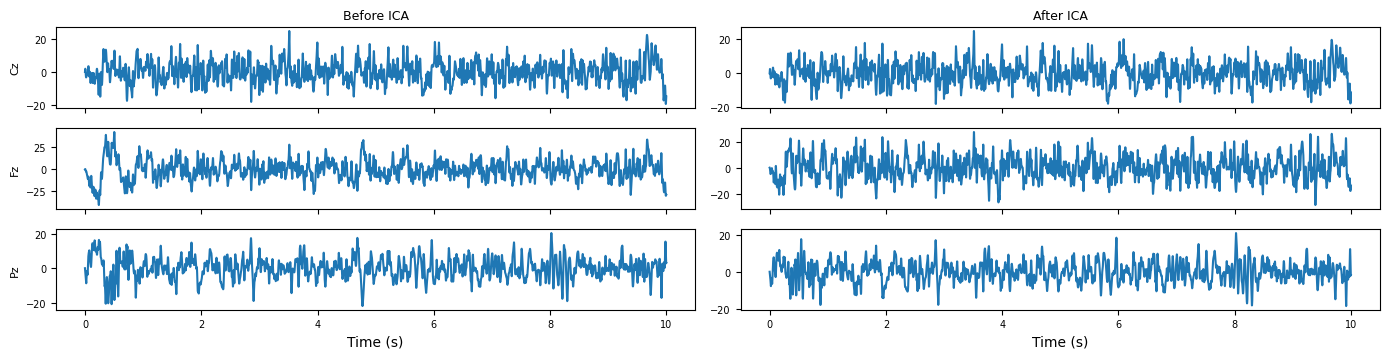

In [14]:
COMPARE_CHANNELS = ["Cz", "Fz", "Pz"]

plot_before_after(raw, raw_clean, COMPARE_CHANNELS, duration=10.0)

## 9. Create epochs

Epochs are locked to rising edges of `STI 014` (DigitalInput1), default window 0–3 s.

In [15]:
TMIN = 0.0   # s relative to stim onset
TMAX = 3.0   # s relative to stim onset

epochs = make_epochs(raw_clean, tmin=TMIN, tmax=TMAX)
print(epochs)
print(f"Shape: {epochs.get_data().shape}  (trials × channels × samples)")

Finding events on: STI 014
104 events found on stim channel STI 014
Event IDs: [1]
Not setting metadata
104 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 104 events and 1537 original time points ...
0 bad epochs dropped
<Epochs | 104 events (all good), 0 – 3 s (baseline off), ~40.3 MiB, data loaded,
 '1': 104>
Shape: (104, 33, 1537)  (trials × channels × samples)


## 10. FBCCA — compute score per epoch

`run_fbcca` applies 5 filter banks ([5–55], [15–55], [25–55], [35–55], [45–55] Hz), computes the maximum canonical correlation against a sin/cos reference at `FBCCA_FREQ` for each bank, then combines with weights `w_j = j^(−1.25) + 0.25` (Chen 2015).

Set `FBCCA_CHANNELS = None` to use all EEG channels, or provide a list of channel names to restrict the CCA to a spatial subset (e.g. occipital channels for visual SSVEP).

In [16]:
FBCCA_FREQ     = 10.0          # target stimulus frequency in Hz
FBCCA_CHANNELS = None          # None = all EEG; e.g. ["Oz", "O1", "O2"] for occipital only
N_HARMONICS    = 3

scores = run_fbcca(
    epochs,
    freq=FBCCA_FREQ,
    channels=FBCCA_CHANNELS,
    n_harmonics=N_HARMONICS,
)

print(f"n_epochs : {len(scores)}")
print(f"min      : {scores.min():.4f}")
print(f"max      : {scores.max():.4f}")
print(f"mean     : {scores.mean():.4f}")
print(f"std      : {scores.std():.4f}")

n_epochs : 104
min      : 0.5563
max      : 1.9013
mean     : 1.4304
std      : 0.2802


## 11. Plot FBCCA stream

Each point is one epoch (stimulus). x-axis = stimulus number (1-indexed), y-axis = weighted FBCCA score.

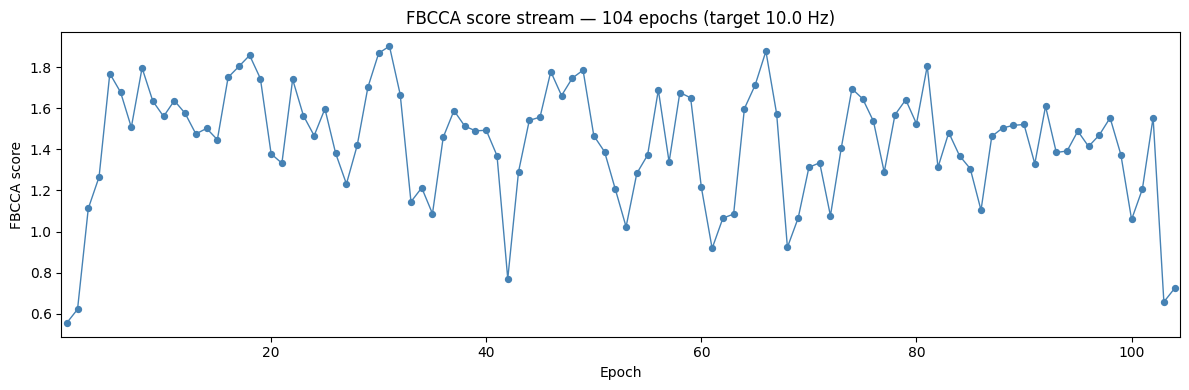

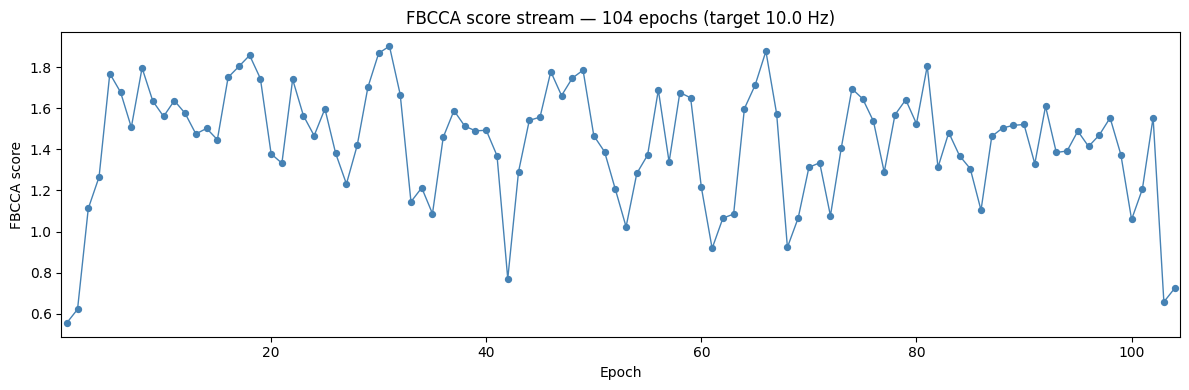

In [17]:
plot_fbcca_stream(scores, freq=FBCCA_FREQ)